VAE
Use: MNIST Handwritten Digits
Kaggle me already available hai via tensorflow.keras

In [74]:
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

In [76]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))

In [77]:
latent_dim = 2

inputs = layers.Input(shape=(28,28,1))
x = layers.Flatten()(inputs)
x = layers.Dense(128, activation='relu')(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

In [78]:
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

In [79]:
decoder_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation='relu')(decoder_inputs)
x = layers.Dense(28*28, activation='sigmoid')(x)
outputs = layers.Reshape((28,28,1))(x)

decoder = Model(decoder_inputs, outputs)

In [80]:
class VAELossLayer(layers.Layer):
    def call(self, inputs):
        x, x_decoded, z_mean, z_log_var = inputs
        
        reconstruction_loss = tf.keras.losses.binary_crossentropy(x, x_decoded)
        reconstruction_loss = tf.reduce_mean(reconstruction_loss)
        
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )
        
        self.add_loss(reconstruction_loss + kl_loss)
        return x_decoded

In [81]:
outputs = decoder(z)

outputs = VAELossLayer()([inputs, outputs, z_mean, z_log_var])

vae = Model(inputs, outputs)
vae.compile(optimizer='adam')

In [82]:
vae.fit(x_train, epochs=10, batch_size=128)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.4268
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2651
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2634
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2630
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2634
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2631
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2628
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2632
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2630
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2630


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


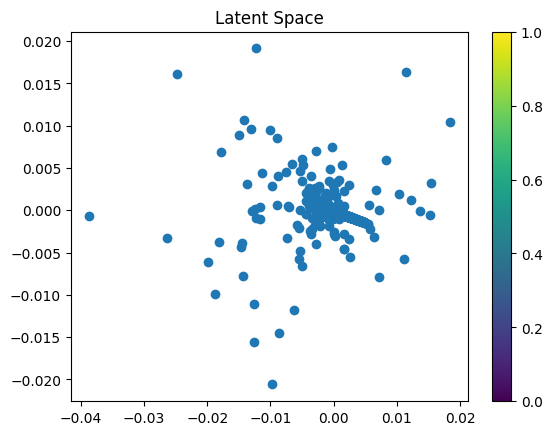

In [83]:
encoder = Model(inputs, z_mean)

z_mean_test = encoder.predict(x_test)

plt.scatter(z_mean_test[:,0], z_mean_test[:,1])
plt.colorbar()
plt.title("Latent Space")
plt.show()

GAN (Image Generation)
Same MNIST

In [84]:
def build_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(100,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(784, activation='sigmoid'),
        layers.Reshape((28,28,1))
    ])
    return model

In [85]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(28,28,1)),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [86]:
generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(optimizer='adam', loss='binary_crossentropy')

z = layers.Input(shape=(100,))
img = generator(z)

discriminator.trainable = False
valid = discriminator(img)

gan = Model(z, valid)
gan.compile(optimizer='adam', loss='binary_crossentropy')

Epoch 0 | D_real: 0.8676624298095703 | D_fake: 0.5402513146400452 | G: 1.5837594270706177


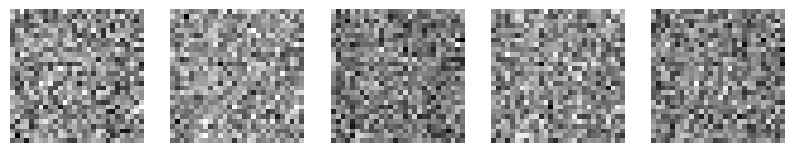

Epoch 200 | D_real: 1.738106369972229 | D_fake: 1.7454153299331665 | G: 0.14491716027259827


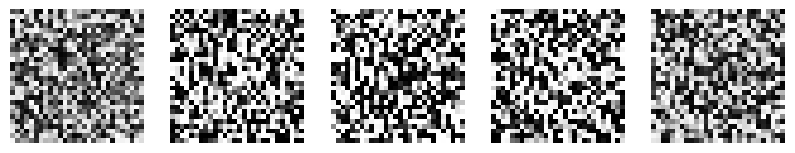

Epoch 400 | D_real: 2.4156134128570557 | D_fake: 2.41975736618042 | G: 0.07514891028404236


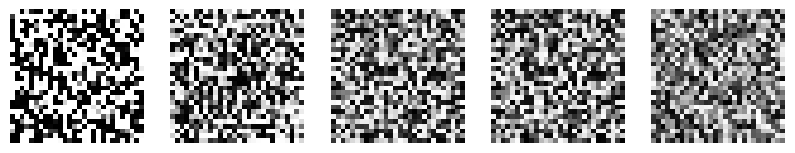

Epoch 600 | D_real: 2.7580113410949707 | D_fake: 2.760996103286743 | G: 0.05101621523499489


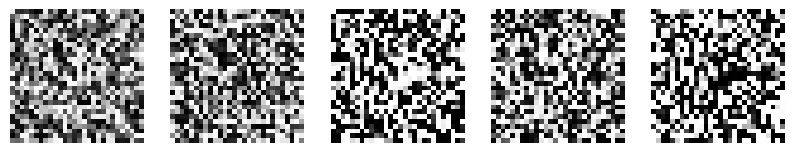

Epoch 800 | D_real: 2.98861026763916 | D_fake: 2.9909307956695557 | G: 0.038691990077495575


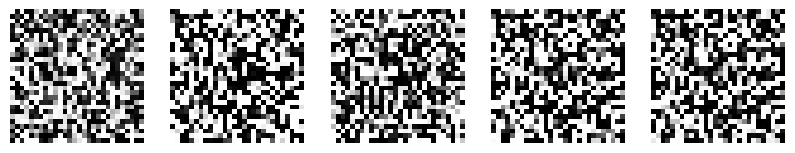

Epoch 1000 | D_real: 3.164137363433838 | D_fake: 3.1660869121551514 | G: 0.031190479174256325


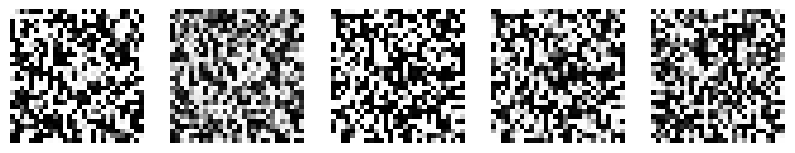

Epoch 1200 | D_real: 3.3079049587249756 | D_fake: 3.3095617294311523 | G: 0.026139289140701294


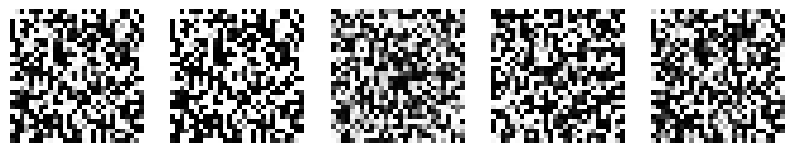

Epoch 1400 | D_real: 3.4276583194732666 | D_fake: 3.429107666015625 | G: 0.02250347100198269


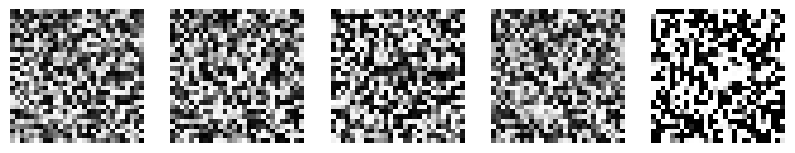

In [87]:
epochs = 1500
batch_size = 64

for epoch in range(epochs):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]

    noise = np.random.normal(0,1,(batch_size,100))
    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size,1)))

    noise = np.random.normal(0,1,(batch_size,100))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D_real: {d_loss_real} | D_fake: {d_loss_fake} | G: {g_loss}")
        show_images()

GCN (Graph Neural Network)
Use: Cora Citation Dataset

In [95]:
!pip install spektral

In [110]:
import numpy as np
import tensorflow as tf

In [137]:
from spektral.datasets import citation

dataset = citation.Cora()
graph = dataset[0]

x, a, y = graph.x, graph.a, graph.y

In [138]:
a = a.toarray()

In [139]:
I = np.eye(a.shape[0])
A_hat = a + I

D = np.sum(A_hat, axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-10))

A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

In [140]:
class SimpleGCN(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.d1 = tf.keras.layers.Dense(32, activation='relu')
        self.d2 = tf.keras.layers.Dense(16, activation='relu')
        self.out = tf.keras.layers.Dense(y.shape[1], activation='softmax')

    def call(self, inputs):
        X, A = inputs
        
        X = tf.matmul(A, X)
        X = self.d1(X)
        
        X = tf.matmul(A, X)
        X = self.d2(X)
        
        X = self.out(X)
        return X

In [144]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [145]:
model.fit(
    [x, A_norm],
    y,
    epochs=100,
    batch_size=x.shape[0],   # 🔥 MOST IMPORTANT
    shuffle=False,           # 🔥 IMPORTANT
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3021 - loss: 1.8527
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.3043 - loss: 1.7519
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.3383 - loss: 1.6549
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.4047 - loss: 1.5567
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.4623 - loss: 1.4541
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.5288 - loss: 1.3514
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.5916 - loss: 1.2506
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.6610 - loss: 1.1528
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.7190 - loss: 1.0632
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.7736 - loss: 0.9781
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.8098 - loss: 0.8963
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.

In [146]:
loss, acc = model.evaluate([x, A_norm], y, batch_size=2708, verbose=0)
print("Accuracy:", acc)

Accuracy: 0.9837518334388733
